# Revisión de matrices de similitud biológica

<div style="text-align: justify;">

Dentro del presente _notebook_ se exponen las alternativas de tratamiento de las matrices de información biológica que se utilizarán en este proyecto. Particularmente, se presentan dos criterios: **mantener la matriz en su estado original** o **deducir un valor para el índice de Wang a partir de un porcentaje de genes cercanos por expresión**. Este componente es principalmente experimental y surgió de las conversaciones con el docente guía de este proyecto.

**Nota:** Adicionalmente, se realizará una revisión de antecedentes en la literatura sobre este tipo de procedimientos, como forma de respaldo.

</div>

In [30]:
############################
# Importaciones
############################
import os                                                   # Llamadas al SO.
import re                                                   # Extracción de nombres de dataset.
import sys                                                  # Límite de recursión (dendrogramas grandes).
from pathlib import Path                                    # Estructura para directorios.
import numpy as np                                          # Manejo de datos numericos.
import pandas as pd
import matplotlib.pyplot as plt                             # Gráficos.
import seaborn as sns                                       # Heatmaps clusterizados.
import fastcluster                                          # Linkage jerárquico rápido.
from scipy.spatial.distance import squareform               # Conversión matriz <-> condensada.
from IPython.display import display                         # Interfaz para mostrar resultados.
from scipy.stats import spearmanr

############################
# Detección de entorno (Colab / Local)
############################
# En Colab (incluido VSCode conectado a un runtime de Colab) el repositorio se
# encuentra clonado en /content/Thesis. En local, se busca la raíz del
# repositorio subiendo desde el directorio de trabajo actual.
try:
    import google.colab                                     # Módulo disponible solo dentro de runtimes de Colab.
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    THESIS_DIR = Path("/content/Thesis")
else:
    _cwd = Path(os.getcwd()).resolve()
    THESIS_DIR = next(
        (p for p in (_cwd, *_cwd.parents) if (p / "Datasets").is_dir() and (p / "Source Code").is_dir()),
        None,
    )
    if THESIS_DIR is None:
        raise FileNotFoundError(f"No se encontró la raíz del repositorio (Datasets/ y Source Code/) desde {_cwd}")

############################
# Constantes
############################
DATA_DIR          = Path(os.getcwd()).resolve() / "Datasets" / "Gene_Expression_source"
OUTPUT_DIR_PREFIX = DATA_DIR / "Results"
MATRICES_DIR = THESIS_DIR / "Datasets" / ("matrices" if IN_COLAB else "Matrices")
print(f"[entorno] {'Colab' if IN_COLAB else 'Local'} → {THESIS_DIR}")

# Matrices de información biológica (_S_DB) y de expresión (_S_DE) disponibles.
# Se descubren automáticamente todos los datasets que tengan AMBOS archivos.
_db_nombres = {
    m.group(1)
    for f in MATRICES_DIR.glob("*_S_DB.npz")
    if (m := re.match(r"^(.+)_S_DB\.npz$", f.name))
}
_de_nombres = {
    m.group(1)
    for f in MATRICES_DIR.glob("*_S_DE.npz")
    if (m := re.match(r"^(.+)_S_DE\.npz$", f.name))
}
DATASETS = sorted(_db_nombres & _de_nombres)
print(f"[datasets] {len(DATASETS)} encontrados: {DATASETS}")

DB_PATHS = {nombre: MATRICES_DIR / f"{nombre}_S_DB.npz" for nombre in DATASETS}
DE_PATHS = {nombre: MATRICES_DIR / f"{nombre}_S_DE.npz" for nombre in DATASETS}

##################################
# Conjunto de funciones.
##################################

def load_distance_matrix(filepath):
    """
    Carga de matrices de distancias en versión comprimioda.
    """
    # Carga de los datos dentro del archivo.
    data = np.load(filepath, allow_pickle=True)
    genes = data["genes"].tolist()

    n = len(genes)                              # Orden de la matriz.
    iu = np.triu_indices(n, k=1)                # índices de la triangular superior.
    M = np.zeros((n, n), dtype=np.float32)      # Matriz nxn.

    # Carga de datos y completar valores de triangular inferior (como diagonal).
    M[iu] = data["upper"]
    M += M.T
    np.fill_diagonal(M, data["diag"])

    # Retroalimentación y sálida.
    print(f"[load] '{filepath.name}' → matriz {n}×{n}. Primer gen: '{genes[0]}', último: '{genes[-1]}'.")
    return 1 - M, genes

def plot_clustered_heatmap(matrix, title, cmap="viridis", figsize=(8, 8)):
    """
    Muestra un heatmap clusterizado (orden jerárquico por similitud) de una
    matriz de distancias ya cargada, directamente en el notebook.

    Se amplía temporalmente el límite de recursión, ya que
    scipy.cluster.hierarchy.dendrogram recorre el linkage de forma recursiva
    y con miles de hojas puede superar el límite por defecto de Python.
    """
    similarity = 1 - matrix
    dist_condensed = squareform(matrix, checks=False)
    linkage = fastcluster.linkage(dist_condensed, method="average")

    old_limit = sys.getrecursionlimit()
    sys.setrecursionlimit(max(old_limit, 100_000))
    try:
        g = sns.clustermap(
            similarity,
            row_linkage=linkage, col_linkage=linkage,
            cmap=cmap, xticklabels=False, yticklabels=False,
            figsize=figsize, rasterized=True,
        )
        g.fig.suptitle(title)
    finally:
        sys.setrecursionlimit(old_limit)

    display(g.fig)
    plt.close(g.fig)

def find_isolated_genes(similarity_matrix):
    """
    Genes aislados: aquellos cuya fila de similitud biológica es enteramente
    0 (omitiéndose a sí mismos, i.e. sin contar la diagonal).
    """
    n = similarity_matrix.shape[0]
    off_diag_mask = ~np.eye(n, dtype=bool)
    off_diag_values = similarity_matrix[off_diag_mask].reshape(n, n - 1)
    return np.where(np.all(off_diag_values == 0, axis=1))[0]

def impute_isolated_genes(bio_similarity, expr_similarity, k):
    """
    Imputa, para cada gen aislado (sin similitud biológica con nadie), su
    fila/columna en la matriz de Wang mediante "guilt-by-association" por
    expresión:

    Para el par (i, j) a imputar, se toman los TOP-k genes más similares
    según expresión a i y a j por separado, y el nuevo valor de Wang(i, j)
    es el promedio de la submatriz biológica k×k formada por esos vecinos
    (sin incluir al propio gen aislado, que no aporta información).

    k es el número de vecinos por expresión y se entrega explícitamente
    (p. ej. el valor seleccionado por validación para cada dataset).

    Devuelve una copia de bio_similarity con las filas/columnas de los
    genes aislados reemplazadas, junto a los índices aislados, sus vecinos
    y el k efectivamente usado.
    """
    n = bio_similarity.shape[0]
    if not (1 <= k < n):
        raise ValueError(f"k debe estar entre 1 y {n - 1} (recibido: {k}).")

    # TOP-k vecinos por expresión de cada gen (excluyendo a sí mismo).
    expr_sim = expr_similarity.copy()
    np.fill_diagonal(expr_sim, -np.inf)
    vecinos = np.argsort(-expr_sim, axis=1)[:, :k]   # (n, k)

    isolados = find_isolated_genes(bio_similarity)
    M_new = bio_similarity.copy()

    # Los nuevos valores se calculan siempre a partir de la matriz original
    # (bio_similarity), para que el orden de procesamiento no afecte el
    # resultado cuando dos genes aislados interactúan entre sí.
    for i in isolados:
        filas_vecinas = bio_similarity[vecinos[i], :]           # (k, n)
        promedio_vecinos_i = filas_vecinas.mean(axis=0)         # (n,) promedio sobre vecinos de i, por gen destino
        fila_nueva = promedio_vecinos_i[vecinos].mean(axis=1)   # (n,) promedio adicional sobre vecinos de cada j
        fila_nueva[i] = M_new[i, i]                             # conserva la diagonal
        M_new[i, :] = fila_nueva
        M_new[:, i] = fila_nueva                                # simetría

    return M_new, isolados, vecinos, k

def evaluar_k(bio_sim, expr_sim, ks, frac=0.15, reps=10, seed=0):
    """
    Función dedicada a evaluar k según las reglas de knn para poder
    realizar una correcta elección de los k vecinos más cercanos.
    """
    # Variables comunes.
    rng = np.random.default_rng(seed)                               # Establecimiento de ambiente pseudoaleatorio.
    aislados0 = find_isolated_genes(bio_sim)                        # Reconocimiento de genes aislados (toda la fila en 0).
    anotados = np.setdiff1d(np.arange(len(bio_sim)), aislados0)     # Reconocimiento de genes anotados (poseen valores de wang).
    out = {k: [] for k in ks}                                       # Salida.

    # Por cada repetición según parametros.
    for _ in range(reps):
        ocultos = rng.choice(anotados, int(frac * len(anotados)), replace=False)        # Sorteo sin repetición una fracción de genes anotados (estos se ocultan para eval. rendimiento).
        resto = np.setdiff1d(anotados, ocultos)                                         # Son los genes que no se han ocultado y se utilizarán para la evaluación.
        B = bio_sim.copy()                                                              # Copia de la matriz de similitud de wang (Gold true) - Diagonal (restauración).
        diag = np.diag(B).copy() 
        B[ocultos, :] = 0; B[:, ocultos] = 0                                            # Transformación de genes anotados ocultos a isolados.
        B[ocultos, ocultos] = diag[ocultos]                                             # Restaura la diagonal.

        # Por cada k puesto en entrada (variantes).
        for k in ks:
            M, _, _, _ = impute_isolated_genes(B, expr_sim, k)                                              # Ejecución de algoritmo impute_isolated_genes generaldo filas ocultas.
            rmse = np.mean([np.sqrt(np.mean((M[h, resto] - bio_sim[h, resto])**2)) for h in ocultos])       # Error cuadratico medio (RMSE) entre fila existente y generada.
            rho  = np.mean([spearmanr(M[h, resto], bio_sim[h, resto]).statistic for h in ocultos])          # Medición de correlación de spearman entre genes (mantiene relación entre genes).
            out[k].append((rmse, rho))
    
    filas = [{"k": k,
        "RMSE_media": np.mean([r[0] for r in v]), "RMSE_std": np.std([r[0] for r in v]),
        "rho_media":  np.mean([r[1] for r in v]), "rho_std":  np.std([r[1] for r in v])}
        for k, v in out.items()]
    return pd.DataFrame(filas).set_index("k").round(4)

[entorno] Local → C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis
[datasets] 5 encontrados: ['A1', 'A2', 'B1', 'B2', 'B3']


## Mantener las matrices en su estado original

<div style="text-align: justify;">

Esta alternativa consiste en conservar el resultado final obtenido en el _notebook_ `Preprocesamiento.ipynb`, presente en este repositorio. Esto genera un escenario exploratorio en el que se dispone de los valores de similitud asociados a la expresión génica, pero con valores faltantes en la información biológica. Ello se debe a que estudiar relaciones específicas entre genes y registrarlas en una ontología demanda un mayor esfuerzo, tanto de análisis como de experimentación. Asimismo, es esperable que no todos los tipos de cáncer o especies cuenten con la misma "cantidad" de información biológica.

[1] Gaudet, P., & Dessimoz, C. (2017). Gene Ontology: Pitfalls, Biases, and Remedies. Methods in molecular biology (Clifton, N.J.), 1446, 189–205. https://doi.org/10.1007/978-1-4939-3743-1_14

[2] Haynes, W.A., Tomczak, A. & Khatri, P. Gene annotation bias impedes biomedical research. Sci Rep 8, 1362 (2018). https://doi.org/10.1038/s41598-018-19333-x 

</div>

In [2]:
##################################
# Carga de matrices (todos los datasets disponibles — información biológica).
##################################
matrices_bi = {}
for nombre, ruta in DB_PATHS.items():
    matrices_bi[nombre] = load_distance_matrix(ruta)

[load] 'A1_S_DB.npz' → matriz 8018×8018. Primer gen: 'A1BG', último: 'ENSG00000285994'.
[load] 'A2_S_DB.npz' → matriz 2705×2705. Primer gen: 'AKT3', último: 'ENSG00000285928'.
[load] 'B1_S_DB.npz' → matriz 3187×3187. Primer gen: 'CDH2', último: 'ENSG00000285973'.
[load] 'B2_S_DB.npz' → matriz 3024×3024. Primer gen: 'A1BG', último: 'ENSG00000284779'.
[load] 'B3_S_DB.npz' → matriz 10616×10616. Primer gen: 'CDH2', último: 'ENSG00000285994'.


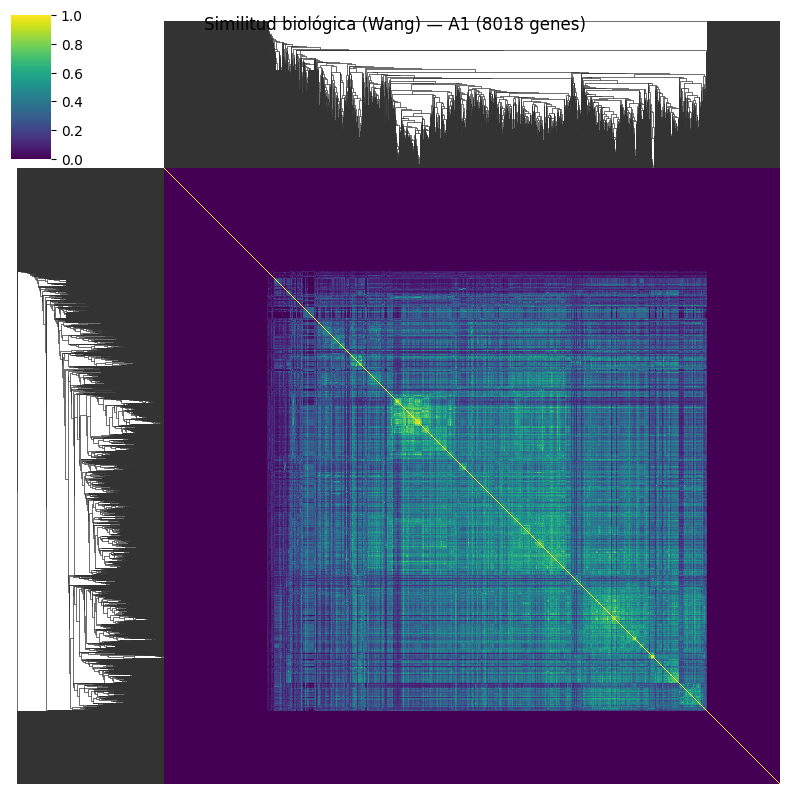

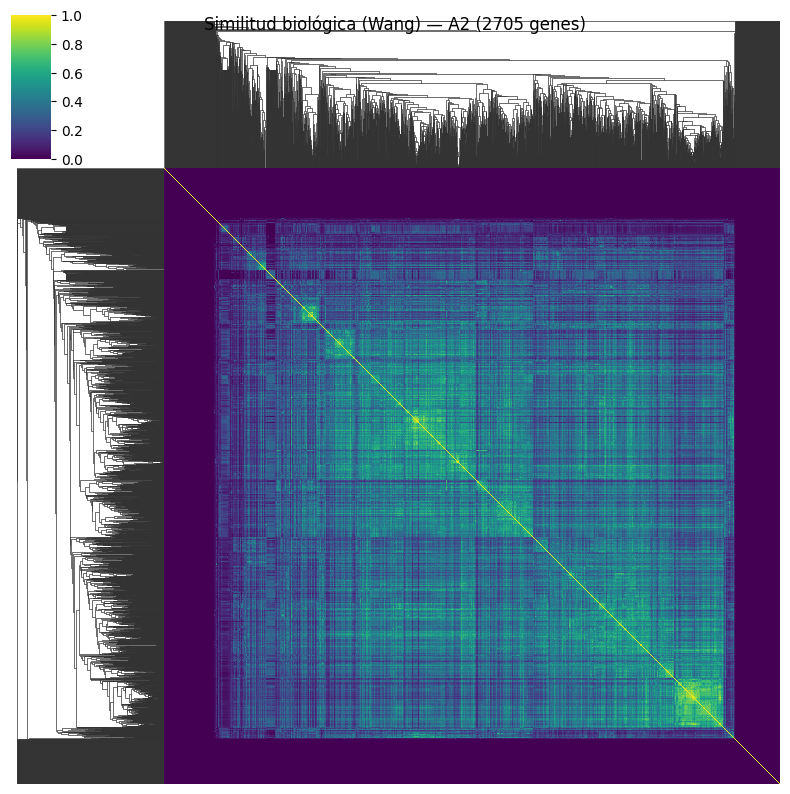

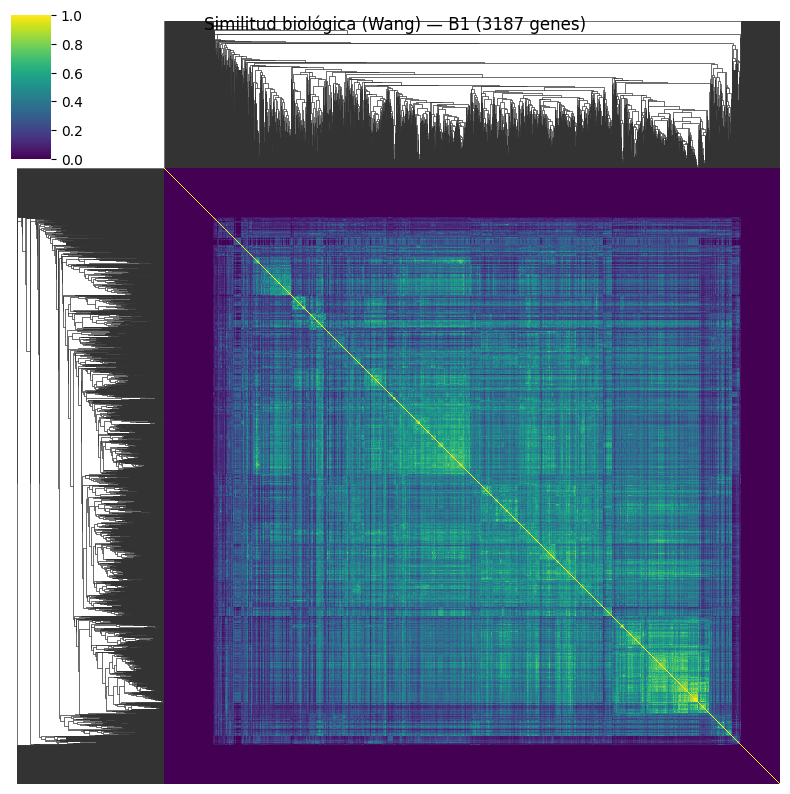

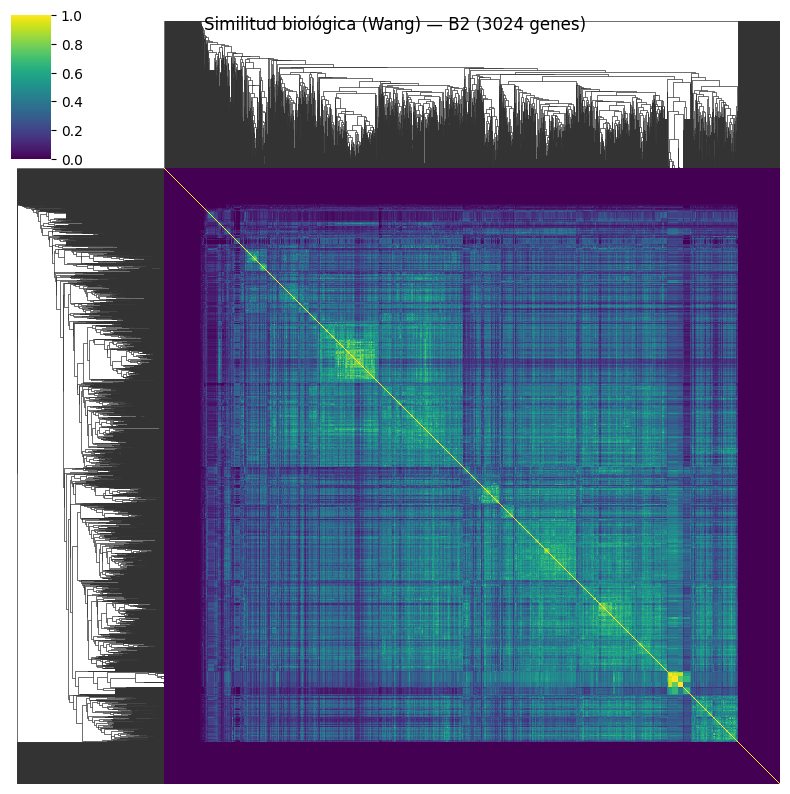

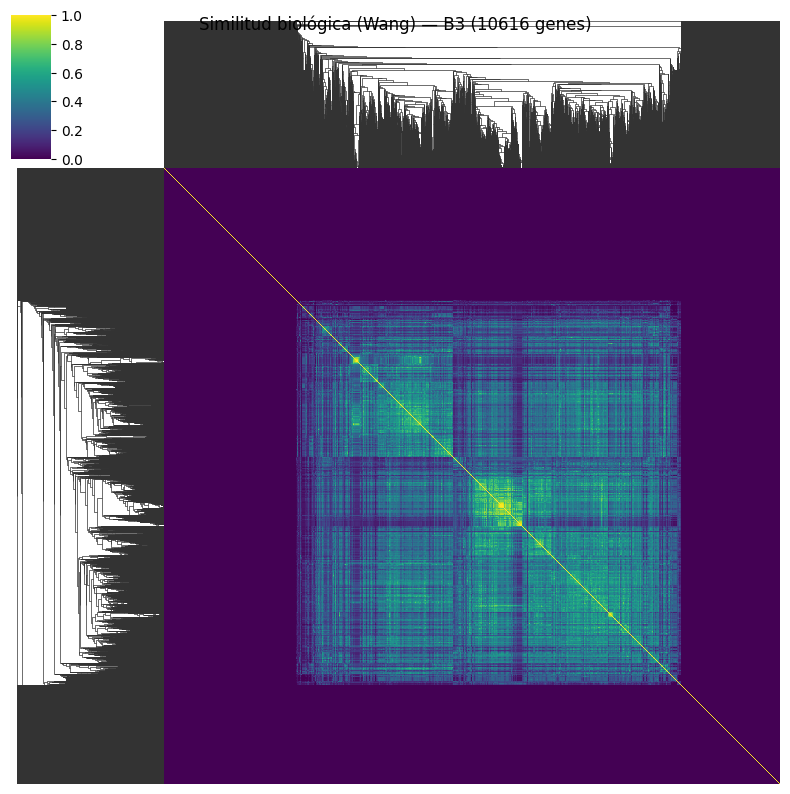

In [3]:
##################################
# Heatmaps clusterizados de similitud biológica (Wang) — todos los datasets.
##################################
for nombre, (distance_matrix, genes) in matrices_bi.items():
    plot_clustered_heatmap(
        distance_matrix,
        title=f"Similitud biológica (Wang) — {nombre} ({len(genes)} genes)",
    )

## Deducir índice de Wang

<div style="text-align: justify;">

Esta alternativa contempla "predecir" los valores del índice de Wang de aquellos genes que presentan valores iguales a 0 en todos sus pares, basándose en un conjunto de genes cercanos a estos según su expresión. Específicamente, para un gen aislado $i$ (con todos los valores de su fila iguales a 0), se calcula el promedio de las filas de sus $k$ genes más cercanos según la distancia de expresión génica, donde $k$ corresponde al 5% del total de genes.

[1] Troyanskaya, O., Cantor, M., Sherlock, G., Brown, P., Hastie, T., Tibshirani, R., Botstein, D., & Altman, R. B. (2001). Missing value estimation methods for DNA microarrays. Bioinformatics, 17(6), 520-525. https://doi.org/10.1093/bioinformatics/17.6.520
</div>

In [4]:
##################################
# Carga de matrices de expresión (todos los datasets) — para hallar vecinos por expresión.
##################################
matrices_de = {}
for nombre, ruta in DE_PATHS.items():
    matrices_de[nombre] = load_distance_matrix(ruta)

[load] 'A1_S_DE.npz' → matriz 8018×8018. Primer gen: 'A1BG', último: 'ENSG00000285994'.
[load] 'A2_S_DE.npz' → matriz 2705×2705. Primer gen: 'AKT3', último: 'ENSG00000285928'.
[load] 'B1_S_DE.npz' → matriz 3187×3187. Primer gen: 'CDH2', último: 'ENSG00000285973'.
[load] 'B2_S_DE.npz' → matriz 3024×3024. Primer gen: 'A1BG', último: 'ENSG00000284779'.
[load] 'B3_S_DE.npz' → matriz 10616×10616. Primer gen: 'CDH2', último: 'ENSG00000285994'.


In [ ]:
FRACCIONES_K = [0.01, 0.02, 0.05, 0.10]            # fracción de genes anotados
resultados_k = {}
for nombre in DATASETS:
    distance_bi, genes = matrices_bi[nombre]
    distance_de, _ = matrices_de[nombre]
    bio_sim, expr_sim = 1 - distance_bi, 1 - distance_de
    n_anot = len(genes) - len(find_isolated_genes(bio_sim))
    ks = sorted({max(2, int(round(f * n_anot))) for f in FRACCIONES_K} | {K_POR_DATASET[nombre]})
    print(f"\n[{nombre}] genes={len(genes)}, anotados={n_anot}, ks={ks}")
    resultados_k[nombre] = evaluar_k(bio_sim, expr_sim, ks, frac=0.15, reps=5, seed=42)
    display(resultados_k[nombre])
    mejor = resultados_k[nombre]["RMSE_media"].idxmin()
    print(f"[{nombre}] k con menor RMSE: {mejor}")


[A1] genes=8018, anotados=5729, ks=[20, 57, 115, 286, 573]


,RMSE_media,RMSE_std,rho_media,rho_std
k,,,,
20,0.1952,0.0010,0.1117,0.0044
57,0.1953,0.0014,0.1199,0.0060
115,0.1971,0.0013,0.1160,0.0040
286,0.2026,0.0011,0.0944,0.0031
573,0.2087,0.0013,0.0701,0.0050


[A1] k con menor RMSE: 20

[A2] genes=2705, anotados=2289, ks=[23, 30, 46, 114, 229]


,RMSE_media,RMSE_std,rho_media,rho_std
k,,,,
23,0.1779,0.0037,0.0803,0.0100
30,0.1779,0.0038,0.0803,0.0111
46,0.1776,0.0034,0.0863,0.0071
114,0.1785,0.0027,0.0877,0.0101
229,0.1817,0.0025,0.0750,0.0111


[A2] k con menor RMSE: 46

[B1] genes=3187, anotados=2733, ks=[27, 30, 55, 137, 273]


,RMSE_media,RMSE_std,rho_media,rho_std
k,,,,
27,0.1897,0.0013,0.1362,0.0045
30,0.1891,0.0016,0.1417,0.0049
55,0.1880,0.0017,0.1628,0.0044
137,0.1877,0.0016,0.1638,0.0030
273,0.1882,0.0012,0.1648,0.0068


[B1] k con menor RMSE: 137

[B2] genes=3024, anotados=2639, ks=[20, 26, 53, 132, 264]


,RMSE_media,RMSE_std,rho_media,rho_std
k,,,,
20,0.1789,0.0022,0.0785,0.0059
26,0.1782,0.0023,0.0863,0.0075
53,0.1781,0.0020,0.0935,0.0085
132,0.1800,0.0017,0.0889,0.0076
264,0.1816,0.0015,0.0725,0.0061


[B2] k con menor RMSE: 53

[B3] genes=10616, anotados=6632, ks=[66, 100, 133, 332, 663]


In [27]:
K_POR_DATASET = {"A1": 20, "A2": 30, "B1": 30, "B2": 20, "B3": 100}   # reemplaza por tus valores

matrices_bi_imputadas = {}
for nombre in DATASETS:
    distance_bi, genes = matrices_bi[nombre]
    distance_de, genes_de = matrices_de[nombre]
    assert genes == genes_de, f"Orden de genes distinto entre DB y DE para {nombre}."

    bio_similarity_imputada, idx_aislados, vecinos, k = impute_isolated_genes(
        1 - distance_bi, 1 - distance_de, k=K_POR_DATASET[nombre],
    )
    print(f"[impute] {nombre}: {len(idx_aislados)}/{len(genes)} genes aislados imputados (k={k}).")

    matrices_bi_imputadas[nombre] = (1 - bio_similarity_imputada, genes)

[impute] A1: 2289/8018 genes aislados imputados (k=20).
[impute] A2: 416/2705 genes aislados imputados (k=30).
[impute] B1: 454/3187 genes aislados imputados (k=30).
[impute] B2: 385/3024 genes aislados imputados (k=20).
[impute] B3: 3984/10616 genes aislados imputados (k=100).


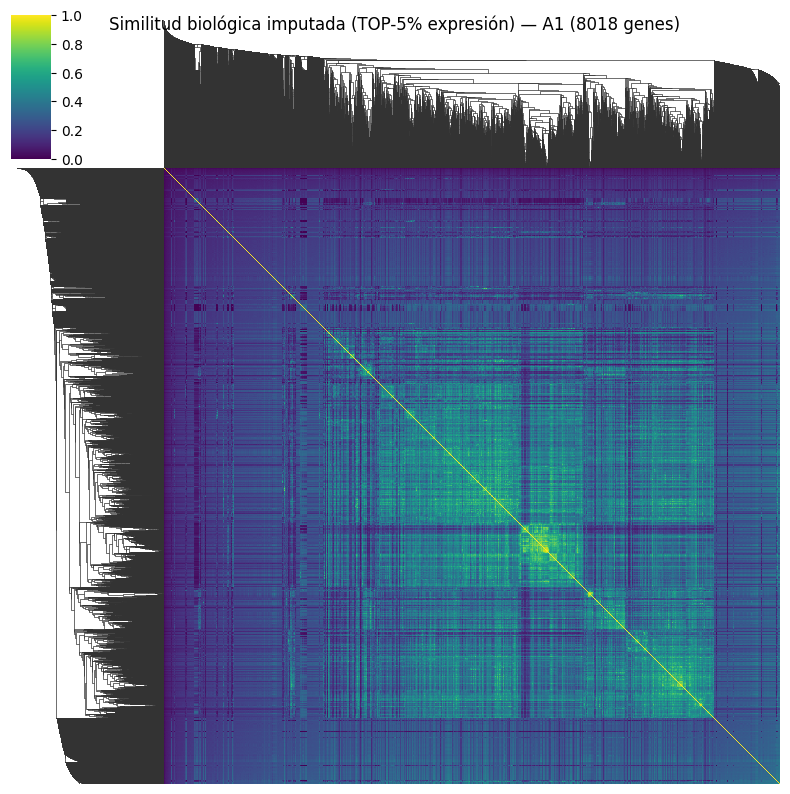

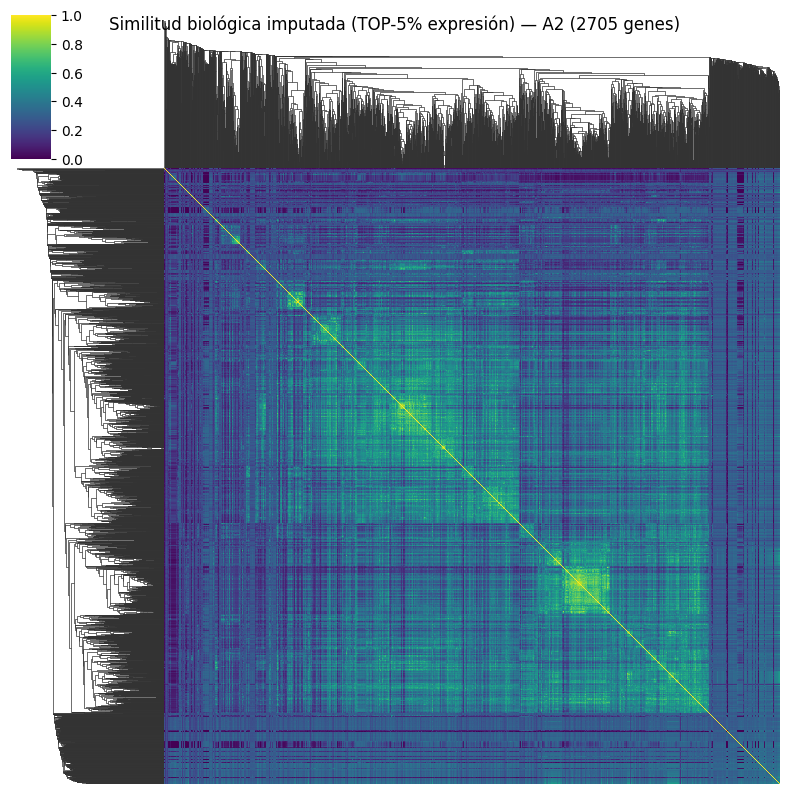

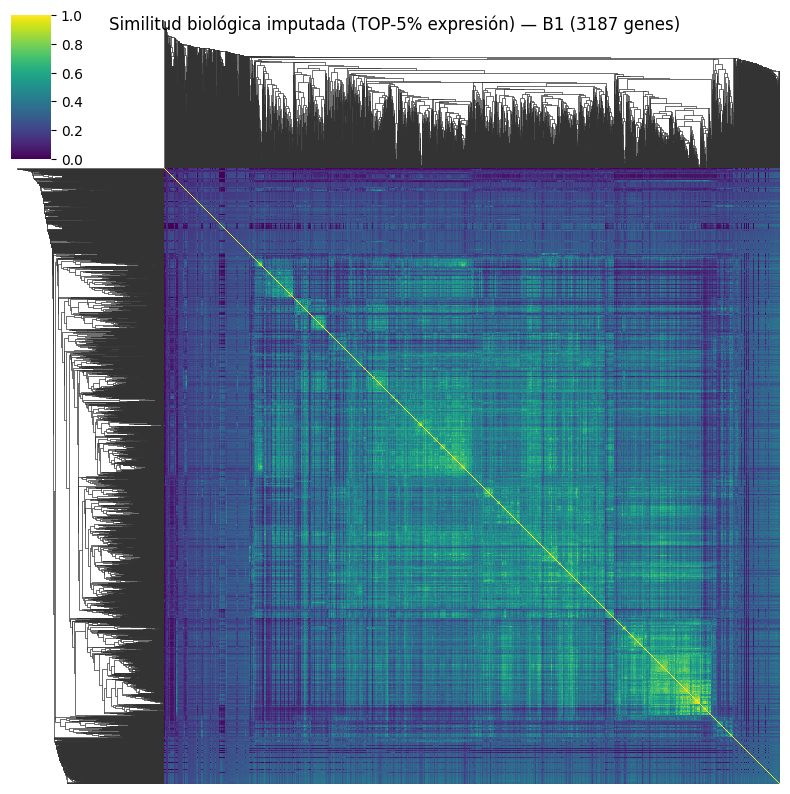

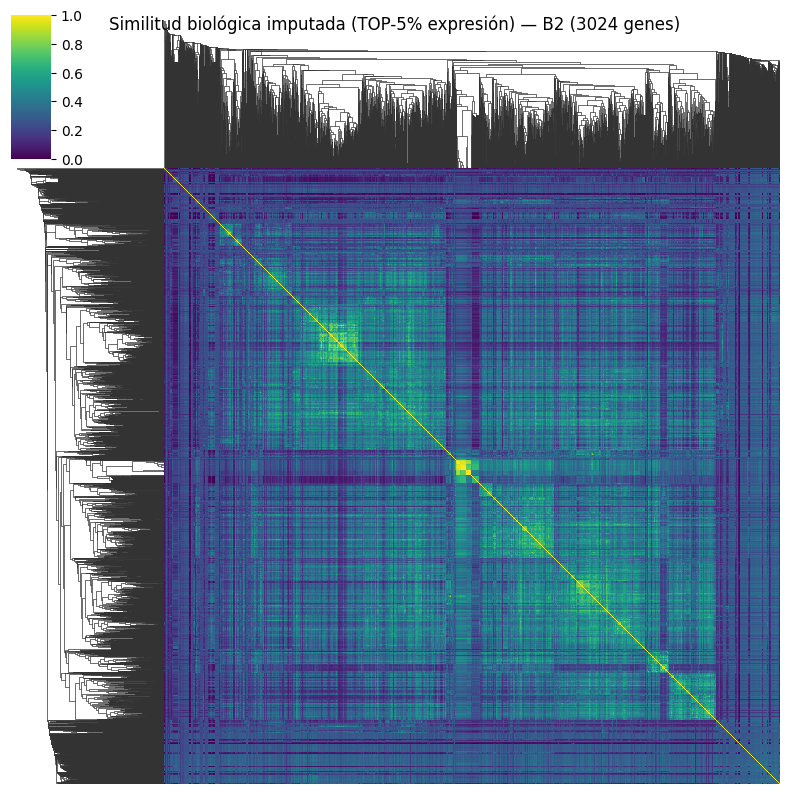

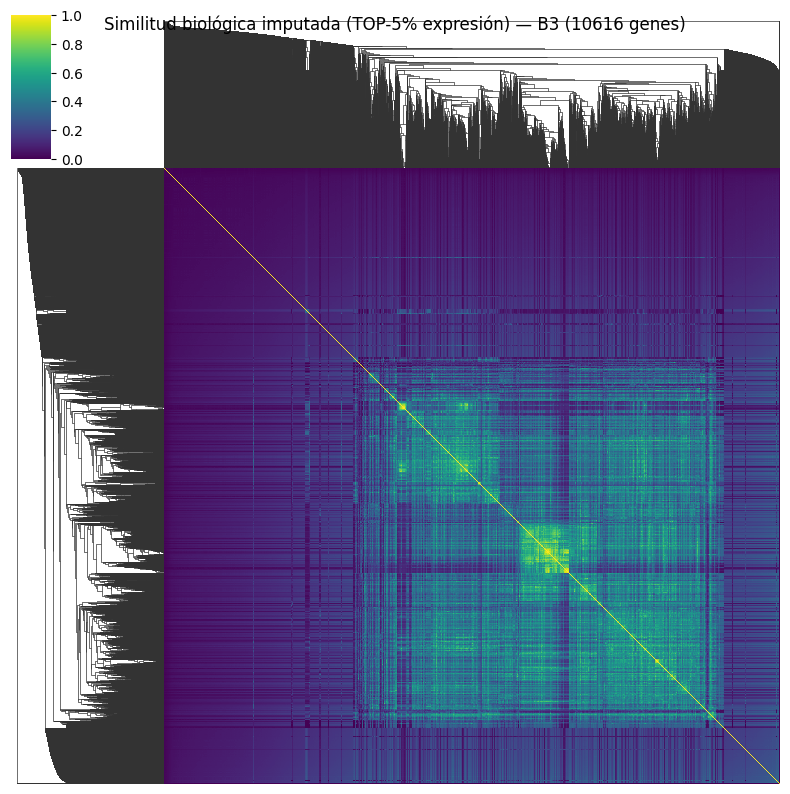

In [28]:
##################################
# Heatmaps clusterizados — matrices biológicas imputadas — todos los datasets.
##################################
for nombre, (distance_matrix, genes) in matrices_bi_imputadas.items():
    plot_clustered_heatmap(
        distance_matrix,
        title=f"Similitud biológica imputada (TOP-5% expresión) — {nombre} ({len(genes)} genes)",
    )

In [7]:
##################################
# Guardado de matrices biológicas imputadas (postfijo '_S_DB_M.npz') en la carpeta Matrices.
##################################
def guardar_matriz_similitud(distance_matrix, genes, filepath):
    """
    Guarda una matriz de distancias como similitud (1 - distancia) en el mismo
    formato comprimido leído por load_distance_matrix: triangular superior
    (sin diagonal), diagonal y lista de genes.
    """
    similarity = 1 - distance_matrix
    iu = np.triu_indices_from(similarity, k=1)
    np.savez_compressed(
        filepath,
        upper=similarity[iu].astype(np.float32),
        diag=np.diag(similarity).astype(np.float32),
        genes=np.array(genes, dtype=object),   # orden gen[i] <-> fila/columna i
    )

MATRICES_DIR.mkdir(parents=True, exist_ok=True)
for nombre, (distance_matrix, genes) in matrices_bi_imputadas.items():
    ruta_salida = MATRICES_DIR / f"{nombre}_S_DB_M.npz"
    guardar_matriz_similitud(distance_matrix, genes, ruta_salida)
    print(f"[save] '{ruta_salida.name}' → matriz {len(genes)}×{len(genes)} guardada en '{MATRICES_DIR}'.")

[save] 'A1_S_DB_M.npz' → matriz 8018×8018 guardada en 'C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis\Datasets\Matrices'.
[save] 'A2_S_DB_M.npz' → matriz 2705×2705 guardada en 'C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis\Datasets\Matrices'.
[save] 'B1_S_DB_M.npz' → matriz 3187×3187 guardada en 'C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis\Datasets\Matrices'.
[save] 'B2_S_DB_M.npz' → matriz 3024×3024 guardada en 'C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis\Datasets\Matrices'.
[save] 'B3_S_DB_M.npz' → matriz 10616×10616 guardada en 'C:\Users\benjamin.gonzalez\Desktop\workspace\Thesis\Datasets\Matrices'.


In [13]:
import numpy as np
from scipy.stats import spearmanr

def eval_k(deb, dbb, annotated_idx, ks, frac=0.15, reps=10, seed=0):
    rng = np.random.default_rng(seed)
    res = {k: [] for k in ks}
    for _ in range(reps):
        hidden = rng.choice(annotated_idx, int(frac*len(annotated_idx)), replace=False)
        known = np.setdiff1d(annotated_idx, hidden)
        for g in hidden:
            order = known[np.argsort(deb[g, known])]          # vecinos por expresión
            for k in ks:
                nn = order[:k]
                pred = dbb[np.ix_(nn, known)].mean(axis=0)    # fila deducida
                true = dbb[g, known]
                res[k].append((np.sqrt(np.mean((pred-true)**2)),
                               spearmanr(pred, true).statistic))
    return {k: np.mean(v, axis=0) for k, v in res.items()}   # (RMSE, rho) por k